In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

### Set confituration for all d_ij(BMF)

In [3]:
x = np.linspace(-40, 40, 801)
mock_data = pd.DataFrame()
mock_data["position"] = x

In [4]:
meta_base = {
  "sample": "BMF_mock",
  "material": "BaMgF4",
  "method": "rotation",
  "wavelength_nm": 1064.0,
  "ref_ch": 1,
  "sig_ch": 2,
  "repetition": "1000Hz",
  "operator": "user",
  "notes": "",
  "start": -40.0,
  "end": 40.0,
  "step": 0.1,
  "timestamp": "2026-01-01T12:00:00.000000",
  "thickness_info": {
    "wedge_angle_deg": 0.0,
    "t_center_mm": 1.0
  },
  "beam_r_x": 359.6,
  "beam_r_y": 423.2
}

#### d_15

In [5]:
meta_d15 = copy.deepcopy(meta_base)
meta_d15["crystal_orientation"] = "010"
meta_d15["rot/trans_axis"] = "100"
meta_d15["input_polarization"] = 45.0
meta_d15["detected_polarization"] = 0.0

#### d_24

In [6]:
meta_d24 = copy.deepcopy(meta_base)
meta_d24["crystal_orientation"] = "100"
meta_d24["rot/trans_axis"] = "010"
meta_d24["input_polarization"] = 45.0
meta_d24["detected_polarization"] = 0.0

In [7]:
from fitting_strategies.bechthold1977 import Bechthold1977Strategy
from fitting_strategies.shoji1997 import Shoji1997RotationStrategy

# StrategyClass = Bechthold1977Strategy
StrategyClass = Shoji1997RotationStrategy

In [8]:
from shg_analysis import SHGDataAnalysis
from crystaldatabase import CRYSTALS
from crystaldatabase import *

analyses = {}
strategies = {}
meta_dict = {
    "d15": meta_d15,
    "d24": meta_d24,
}

for dij, meta in meta_dict.items():
    analysis = SHGDataAnalysis(
        mock_input={
            "meta": meta,
            "data": mock_data,
        }
    )
    strategy = StrategyClass(analysis)

    analyses[dij] = analysis
    strategies[dij] = strategy

### Theoretical fringe for a given thickness

#### d_15, y-cut

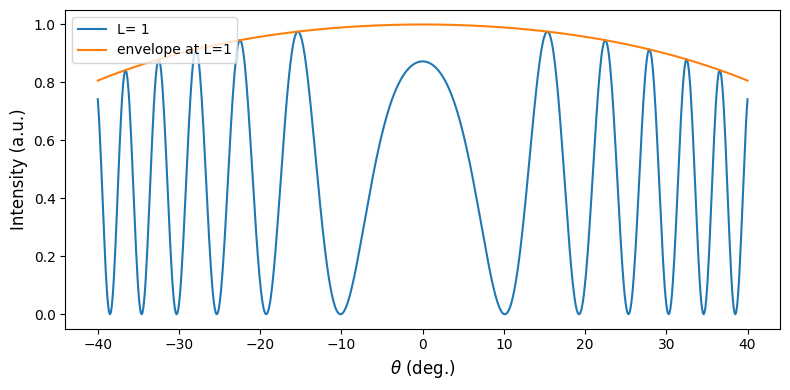

In [9]:
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(8, 4))

# L = 0.77
L = 1
fringe = strategies["d15"]._maker_fringes(override={"L":L})
envelope = strategies["d15"]._maker_fringes(override={"L":L}, envelope=True)
ax.plot(x, fringe, label=f'L= {L}')
ax.plot(x, envelope, label=f'envelope at L={L}')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 3)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

#### d_24, x-cut

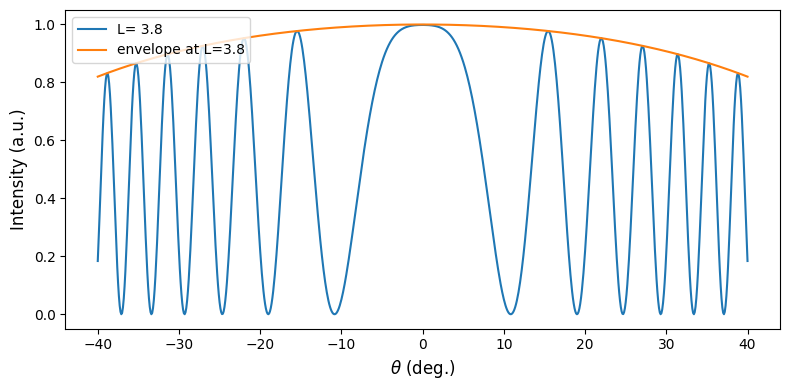

In [10]:
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(8, 4))

L = 3.8
fringe = strategies["d24"]._maker_fringes(override={"L":L})
envelope = strategies["d24"]._maker_fringes(override={"L":L}, envelope=True)
ax.plot(x, fringe, label=f'L= {L}')
ax.plot(x, envelope, label=f'envelope at L={L}')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 3)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Calculate signal dependent on L at theta=0

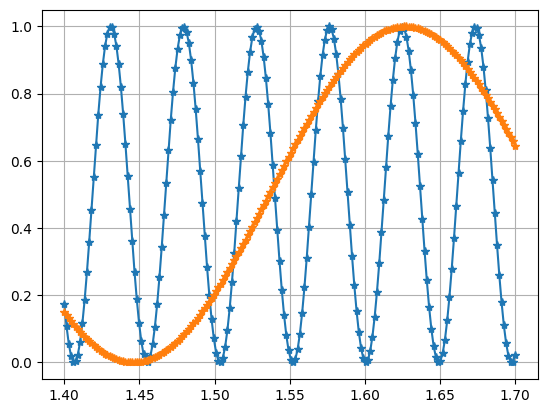

In [11]:
thickness = np.linspace(1.4, 1.7, 200)
y_d15 = []
for i in thickness:
    y = strategies["d15"]._maker_fringes(override={"L":i, "theta_deg":0})
    y_d15.append(y)


y_d24 = []
for i in thickness:
    y = strategies["d24"]._maker_fringes(override={"L":i, "theta_deg":0})
    y_d24.append(y)

plt.plot(thickness, y_d15, "-*")
plt.plot(thickness, y_d24, "-*")
plt.grid(True)
plt.show()


### Check wedge curve

KeyError: 'L_array'

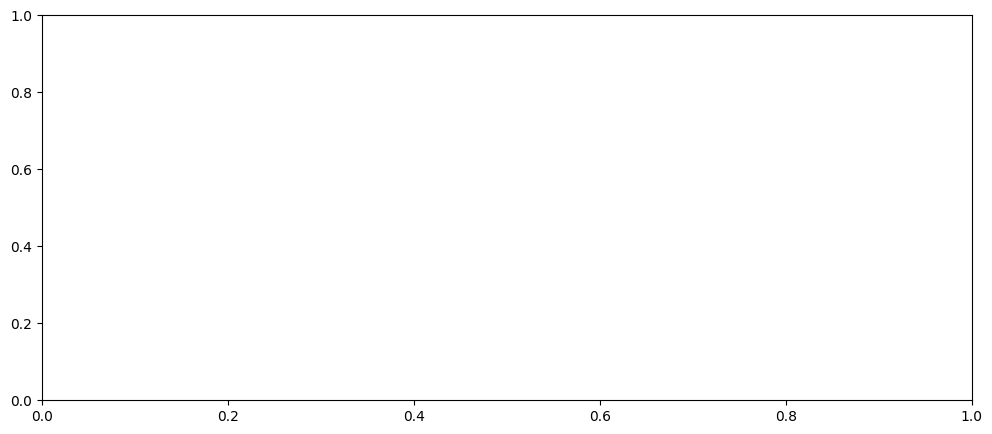

In [12]:
ft_labels = 20
ft_ticks = 18
fig, ax = plt.subplots(figsize=(12, 5))
for dij, strategy in strategies.items():
    fringe, aux = strategy._maker_fringes(
        override={"wedge_deg": 0.3},
        return_aux=True
        )
    thickness = aux["L_array"]
    ax.plot(x, fringe, label=f'BMF {dij}')

# ---- Bottom x-axis (stage position) ----
ax.set_xlabel('Stage position (mm)', fontsize=ft_labels)
ax.set_ylabel('Intensity (a.u.)', fontsize=ft_labels)
ax.tick_params(axis="x", labelsize=ft_ticks)
ax.tick_params(axis="y", labelsize=ft_ticks)
ax.set_ylim(0, 1)

# ---- Top x-axis (crystal thickness) ----
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

# Choose tick positions from stage axis
n_ticks = 9
x_ticks = np.linspace(x.min(), x.max(), n_ticks)

# Interpolate thickness at those positions
thickness_ticks = np.interp(x_ticks, x, thickness)

ax_top.set_xticks(x_ticks)
ax_top.tick_params(axis="x", labelsize=ft_ticks)
ax_top.set_xticklabels([f"{t:.3f}" for t in thickness_ticks])
ax_top.set_xlabel("Crystal thickness (mm)", fontsize=ft_labels)


fig.tight_layout()
ax.legend(loc='upper left')
plt.show()